# Entropy and Information Gain

## Introduction

When a decision tree decides which feature to split on, it needs a way to 
measure "how mixed" a node is. A node with all one class is perfect — zero 
impurity. A node with equal mix of all classes is worst — maximum impurity.

Entropy is one such measure. But it's not arbitrary — it's the **only** 
function that satisfies three logical axioms about uncertainty. This notebook 
derives it from scratch.

Imagine you're teaching a child to identify whether a fruit is an apple or an orange.
You ask questions — *Is it red? Is it round? Is it heavy?* — and based on the answers,
you narrow down the answer. A Decision Tree does exactly this, but it needs to figure
out **which question to ask first**.

The key idea is **impurity**. At any node in the tree, you have a bunch of samples.
If all of them belong to the same class — say, all apples — that node is **pure**.
There's no confusion, no mixing, no uncertainty. But if the node has a mix of apples
and oranges, it's **impure** — the tree hasn't learned anything useful yet.

The tree's job at every step is to pick the feature that **reduces impurity the most**.
A good split takes a messy, mixed-up node and produces children that are cleaner and
more uniform. A bad split changes nothing — the children are just as mixed as the parent.

But to compare splits mathematically, we need a number that **measures impurity**.
That number is **Entropy**.

---

## The Cauchy Axioms

Entropy isn't a formula someone pulled out of thin air. Shannon asked a deeper question:
*What properties must any reasonable measure of uncertainty satisfy?* He came up with
three axioms — logical requirements that any sensible impurity measure should obey.
The remarkable result: **only one function satisfies all three.**

### Axiom 1 — Continuity
> $H(p_1, p_2, \ldots, p_C)$ must be a continuous function of the probabilities.

**Plain English:** A tiny change in class proportions should cause only a tiny change
in uncertainty. Uncertainty shouldn't jump or spike wildly when probabilities shift
slightly. This makes the measure stable and well-behaved.

### Axiom 2 — Symmetry
> $H(p_1, p_2, \ldots, p_C) = H(p_{\sigma(1)}, p_{\sigma(2)}, \ldots, p_{\sigma(C)})$
> for any permutation $\sigma$.

**Plain English:** It doesn't matter which class you label "Class 1" or "Class 2".
The uncertainty in a dataset with 30% cats and 70% dogs is the same as 70% cats and
30% dogs. The *names* of the classes don't affect how mixed the data is.

### Axiom 3 — Additivity (the key one)
> If you split a choice into successive steps, the total entropy should be the
> **weighted sum** of the entropies at each step.

**Plain English:** If you first decide between groups, then decide within each group,
the total uncertainty is the uncertainty of the group choice **plus** the weighted
average uncertainty within each group. Uncertainty compounds in a consistent,
additive way.

---

**Shannon's Result:**

Shannon proved that the **only** function satisfying all three axioms is:

$$\boxed{H = -\sum_{c=1}^{C} p_c \log_2 p_c}$$

This is not a design choice. It is a mathematical inevitability.

---

## Deriving the Entropy Formula

We start from the **Additivity Axiom** and build the formula from scratch.

---

**Setup:** Suppose all $C$ classes are equally likely, each with probability
$p_c = \frac{1}{C}$. Call this uniform entropy $H_C$.

**Step 1 — Additivity for uniform distributions:**

If you have $C \times M$ equally likely outcomes, you can think of the choice in two
stages: first pick one of $C$ groups (each with probability $\frac{1}{C}$), then
pick one of $M$ items within that group. By the additivity axiom:

$$H_{CM} = H_C + H_M$$

This means: *total uncertainty = uncertainty between groups + uncertainty within groups.*

---

**Step 2 — The only function satisfying this is logarithm:**

The equation $H_{CM} = H_C + H_M$ must hold for all $C$ and $M$. This is the
**Cauchy functional equation** for logarithms. The only continuous solution is:

$$H_C = k \log C$$

for some constant $k > 0$.

*Why?* Because logarithms are the only functions that convert multiplication into
addition: $\log(CM) = \log C + \log M$.

---

**Step 3 — Extend to non-uniform probabilities:**

Now let classes have unequal probabilities $p_1, p_2, \ldots, p_C$. Approximate each
$p_c$ as a rational number $\frac{n_c}{N}$ where $N = \sum n_c$.

Think of it as $N$ equally likely micro-outcomes, grouped into $C$ classes where
class $c$ contains $n_c$ micro-outcomes. By additivity:

$$H_N = H(p_1, \ldots, p_C) + \sum_{c=1}^{C} p_c \cdot H_{n_c}$$

*The left side is the total uniform entropy. The right side is: entropy between
classes + weighted entropy within each class.*

---

**Step 4 — Substitute $H_N = k \log N$ and $H_{n_c} = k \log n_c$:**

$$k \log N = H(p_1, \ldots, p_C) + \sum_{c=1}^{C} p_c \cdot k \log n_c$$

Rearranging:

$$H(p_1, \ldots, p_C) = k \log N - k \sum_{c=1}^{C} p_c \log n_c$$

$$= k \sum_{c=1}^{C} p_c \log N - k \sum_{c=1}^{C} p_c \log n_c$$

*(used the fact that $\sum p_c = 1$, so $k \log N = k \sum p_c \log N$)*

---

**Step 5 — Combine into a single sum:**

$$H = k \sum_{c=1}^{C} p_c \left(\log N - \log n_c\right) = k \sum_{c=1}^{C} p_c \log \frac{N}{n_c}$$

Since $\frac{n_c}{N} = p_c$, we have $\frac{N}{n_c} = \frac{1}{p_c}$:

$$H = k \sum_{c=1}^{C} p_c \log \frac{1}{p_c} = -k \sum_{c=1}^{C} p_c \log p_c$$

---

**Step 6 — Fix the constant $k$:**

We want entropy in **bits**, so we set $k = 1$ and use $\log_2$. This gives maximum
entropy of 1 bit for a fair binary choice — a natural unit.

$$\boxed{H(S) = -\sum_{c=1}^{C} p_c \log_2 p_c}$$

**Every step was forced by logic.** No arbitrary choices were made.

---

## Properties of Entropy

### Property 1 — Pure Node Has Zero Entropy

If one class has probability 1 (say $p_1 = 1$, all others = 0):

$$H = -(1 \cdot \log_2 1) = -(1 \cdot 0) = 0$$

**Why:** $\log_2(1) = 0$, and the $0 \log_2 0$ terms vanish by convention.
Zero entropy means zero uncertainty — the node is perfectly pure.

---

### Property 2 — Uniform Distribution Maximizes Entropy

Entropy is maximum when all $C$ classes are equally likely: $p_c = \frac{1}{C}$.

$$H_{\max} = -\sum_{c=1}^{C} \frac{1}{C} \log_2 \frac{1}{C} = \log_2 C$$

**Why:** Equal probabilities = maximum confusion. You know nothing about which class
a sample belongs to. This can be proven formally using Jensen's inequality (since
$\log$ is concave), but the intuition is clear.

---

### Property 3 — Binary Entropy Peaks at p = 0.5

For binary classification with positive class proportion $p$:

$$H(p) = -p \log_2 p - (1-p) \log_2(1-p)$$

Setting $\frac{dH}{dp} = 0$ gives $p = 0.5$, where $H = 1$ bit — maximum uncertainty.

| $p$ | $H(p)$ |
|-----|--------|
| 0.0 | 0.000 |
| 0.1 | 0.469 |
| 0.3 | 0.881 |
| 0.5 | 1.000 |
| 0.7 | 0.881 |
| 0.9 | 0.469 |
| 1.0 | 0.000 |

---

### Binary Entropy Curve

*(Plot H vs p for $p \in [0, 1]$ — bell-shaped curve peaking at p=0.5)*

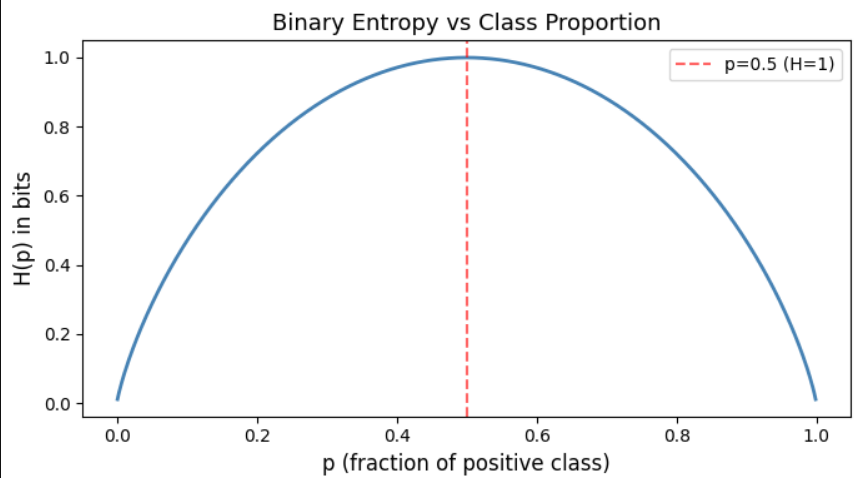

---

## Conditional Entropy

### Definition

$$H(Y \mid X) = \sum_{v \in \text{Values}(X)} P(X = v) \cdot H(Y \mid X = v)$$

**Plain English:** Conditional entropy answers the question —
*"After I know the value of feature X, how much uncertainty about Y still remains?"*

If knowing $X$ completely determines $Y$, then $H(Y \mid X) = 0$. If $X$ tells you
absolutely nothing about $Y$, then $H(Y \mid X) = H(Y)$.

---

### Why It's a Weighted Average

Each value $v$ of $X$ creates a subset of the data. The entropy $H(Y \mid X = v)$
measures how mixed the labels are in that subset. But subsets can be different sizes
— a subset with 8 out of 10 samples matters more than one with 2 out of 10. So we
**weight each child's entropy by the fraction of samples it contains**:

$$H(Y \mid X) = \frac{|S_1|}{|S|} H(S_1) + \frac{|S_2|}{|S|} H(S_2) + \cdots$$

A large impure child drags the weighted average up. A small impure child has less
influence. This is exactly what we want — the split is judged by the overall
post-split uncertainty, not just the worst child.

---

## Information Gain

### Definition

$$IG(Y, X) = H(Y) - H(Y \mid X)$$

**Plain English:** Information Gain is the **reduction in uncertainty** that feature
$X$ gives you about label $Y$. High IG means the split is very useful — the children
are much purer than the parent. Low IG means the split barely helps.

The Decision Tree greedily picks the feature with the **highest** IG at each node.

---

### Manual Example — Step by Step

**Dataset:** 10 samples at the parent node — 6 positive (+), 4 negative (−)

**Step 1 — Parent entropy:**

$$H(S) = -\frac{6}{10}\log_2\frac{6}{10} - \frac{4}{10}\log_2\frac{4}{10}$$

$$= -0.6 \times (-0.737) - 0.4 \times (-1.322) = 0.442 + 0.529 = 0.971 \text{ bits}$$

---

**Step 2 — Split on Feature A:**

- Left child $S_L$: 5 samples → 4+, 1−
- Right child $S_R$: 5 samples → 2+, 3−

---

**Step 3 — Left child entropy:**

$$H(S_L) = -\frac{4}{5}\log_2\frac{4}{5} - \frac{1}{5}\log_2\frac{1}{5}$$

$$= -0.8 \times (-0.322) - 0.2 \times (-2.322) = 0.258 + 0.464 = 0.722 \text{ bits}$$

---

**Step 4 — Right child entropy:**

$$H(S_R) = -\frac{2}{5}\log_2\frac{2}{5} - \frac{3}{5}\log_2\frac{3}{5}$$

$$= -0.4 \times (-1.322) - 0.6 \times (-0.737) = 0.529 + 0.442 = 0.971 \text{ bits}$$

---

**Step 5 — Weighted conditional entropy:**

$$H(Y \mid X) = \frac{5}{10}(0.722) + \frac{5}{10}(0.971) = 0.361 + 0.486 = 0.846 \text{ bits}$$

---

**Step 6 — Information Gain:**

$$IG = H(S) - H(Y \mid X) = 0.971 - 0.846 = \mathbf{0.125 \text{ bits}}$$

This split removed **0.125 bits** of uncertainty. Compare this across all features —
the one with the highest IG wins.

---

## Why Log Base 2?

Using $\log_2$ gives entropy in **bits** — the standard unit of information in
computer science. One bit is exactly the uncertainty of a fair coin flip.

Other bases are valid and used in different fields:

| Log Base | Unit | Used In |
|----------|------|---------|
| $\log_2$ | Bits | Information theory, CS, Decision Trees |
| $\ln$ (base $e$) | Nats | Statistics, Physics |
| $\log_{10}$ | Hartleys | Early information theory |

**The base only scales the entropy value.** It does not change the ranking of
features by Information Gain — if Feature A beats Feature B with $\log_2$, it
beats Feature B with $\ln$ too.

This means `sklearn`'s `criterion='entropy'` works correctly regardless of which
base it uses internally, because it's always comparing features against each other,
never against an absolute threshold.

---

## Limitations of Entropy as a Criterion

### Problem 1 — Bias Toward High-Cardinality Features

Information Gain has a well-known flaw: it **favors features with many unique values**.

Consider a feature like `CustomerID` — every sample has a unique value. Splitting on
it would create $N$ children, each with exactly 1 sample, each perfectly pure
($H = 0$). The IG would be maximum — yet this split is completely useless for
generalization. It just memorizes the training data.

This problem gets worse as a feature's number of unique values increases. A continuous
feature with many thresholds, or a categorical feature with many categories, will
often beat genuinely informative but simpler features.

### Problem 2 — Gain Ratio as the Fix

To correct this, Ross Quinlan introduced the **Gain Ratio** in the C4.5 algorithm:

$$\text{Gain Ratio}(S, A) = \frac{IG(S, A)}{H_A(S)}$$

where $H_A(S) = -\sum_v \frac{|S_v|}{|S|}\log_2\frac{|S_v|}{|S|}$ is the
**Split Information** — how broadly feature $A$ disperses the data.

A feature that splits data into many small fragments gets a large denominator,
penalizing its raw IG. This normalizes the gain and corrects the cardinality bias.
Gain Ratio is the default criterion in C4.5; `sklearn`'s Decision Tree uses
**Gini Impurity** as an alternative that avoids this issue differently.